# BioJEPA v1.0 Training Pipeline

Assumes the composer is already trained (locall) using the [train_composer_v1_0.ipynb](train_composer_v1_0.ipynb) notebook.

In [1]:
import torch
import random
import gc
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import numpy as np

from biojepa_v1_0 import BioJepa, BioJepaConfig
from dataloader_v1_0 import EncoderLoader, ComposerLoader, TrainingLoader
from training_v1_0 import create_model, load_feature_banks, run_encoder_training, run_composer_training, run_ac_training, train_linear_decoder, maybe_compile
from config_v1_0 import EncoderTrainingConfig, ComposerTrainingConfig, ACTrainingConfig, DecoderConfig, DataConfig
from evals.evals import EvalContext, run_encoder_evals, run_composer_evals, run_ac_evals, save_report

## Device & Paths

In [2]:
SEED = 1337

def get_device():
    device = 'cpu'
    if torch.cuda.is_available():
        torch.cuda.manual_seed(SEED)
        device = 'cuda'
    print(f'using {device}')
    return torch.device(device)

torch.manual_seed(SEED)
random.seed(SEED)
torch.set_float32_matmul_precision('high')

device = get_device()

USE_AMP = torch.cuda.is_available()
USE_COMPILE = torch.cuda.is_available()
USE_FUSED = torch.cuda.is_available()

using cuda


In [3]:
data_root = Path('~/data/jepa/v1_0').expanduser()
ref_root = Path('~/data/jepa/reference_data').expanduser()

data_cfg = DataConfig(
    data_root=data_root,
    checkpoint_dir=data_root / 'checkpoint',
    ref_dir = ref_root,
    eval_results_dir=data_root / 'eval_results'
)

data_cfg.checkpoint_dir.mkdir(parents=True, exist_ok=True)
data_cfg.eval_results_dir.mkdir(parents=True, exist_ok=True)

## Hyperparameters

In [4]:
# Model architecture based on HPO for encoder, composer, and predictor
model_cfg = BioJepaConfig(
    num_genes=10000,
    n_layer=6,
    heads=4,
    embed_dim=256,
    mlp_ratio=4.0,
    n_pre_layer=2,
    mask_ratio=0.766,
    gaussian_scale=5.699,
    film_linear_multiple=0.6769,
    sim_coeff=50.18,
    std_coeff=25.44,            # sim_coeff * std_to_sim_ratio (0.5069)
    cov_coeff=0.5158,           # sim_coeff * cov_to_sim_ratio (0.01028)
    pert_latent_dim=128,
    pert_mode_dim=64,
    predictor_embed_dim=128,
    predictor_n_layer=4,
    predictor_heads=4,
)

# Encoder config based on 10 epochs, but we stop at epoch 3.
encoder_cfg = EncoderTrainingConfig(
    epochs=10, stop_after_epochs=3, lr=6.126e-5, batch_size=64,
    warmup_pct=0.25, weight_decay=0.05, phase2_start_pct=0.8,
    context_coeff=0.0, ema_final_momentum=None
)

composer_cfg = ComposerTrainingConfig(
    epochs=10000, lr=2.147e-4, batch_size=64, weight_decay=2.512e-3, temperature=7.559e-4, chemical_fraction=0.1,
)

ac_cfg = ACTrainingConfig(
    epochs=5, predictor_lr=4e-3, batch_size=64, beta_nll_target=0.95,
    mask_anneal_pct=0.4, mask_anneal_floor=0.0, composer_lr_mult=0.01,
)

decoder_cfg = DecoderConfig(epochs=5, lr=1e-3, batch_size=32)

## Initialize Model & Data

In [5]:
model = create_model(model_cfg, device)
seq_banks, target_bank = load_feature_banks(data_cfg, device)

print(f'Student/Teacher: {sum(p.numel() for p in model.student.parameters() if p.requires_grad):,}')
print(f'ACpredictor: {sum(p.numel() for p in model.predictor.parameters() if p.requires_grad):,}')
print(f'PerturbationComposer: {sum(p.numel() for p in model.composer.parameters() if p.requires_grad):,}')

Loaded DNA embeddings: torch.Size([11643, 1536])
Loaded chemical embeddings: torch.Size([188, 1536])
Loaded target embeddings: torch.Size([9975, 320])
Student/Teacher: 7,979,522
ACpredictor: 2,565,760
PerturbationComposer: 444,224


## Step 0: Load Composer Checkpoint & Eval

In [6]:
checkpoint_path = data_cfg.checkpoint_dir / 'biojepa_v1_0_composer_final.pt'
with torch.serialization.safe_globals([BioJepaConfig]):
    checkpoint = torch.load(checkpoint_path, map_location=device)

keys = model.load_state_dict(checkpoint['model'])
model = maybe_compile(model, USE_COMPILE)
keys

<All keys matched successfully>

In [7]:
comp_train_loader = ComposerLoader(
    batch_size=composer_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'pert_embd', 
    device=device,
    seed=1337, chemical_fraction=composer_cfg.chemical_fraction)
comp_val_loader = ComposerLoader(
    batch_size=composer_cfg.batch_size, 
    split='val', data_dir=data_cfg.data_root / 'pert_embd', 
    device=device)

found 1 shards for split train
  modality balancing: target chemical_fraction=10%
  adjusted total_samples=11829 (from 1 shards)
found 1 shards for split val


In [ ]:
eval_config = {
    'num_genes': model_cfg.num_genes, 'embed_dim': model_cfg.embed_dim,
    'n_layer': model_cfg.n_layer, 'heads': model_cfg.heads, 'batch_size': composer_cfg.batch_size, 'seed': SEED
}
model.eval()
align_eval_ctx = EvalContext(config=eval_config, data_root=data_cfg.data_root, checkpoint_root=data_cfg.data_root, ref_dir=data_cfg.ref_dir)
align_eval_ctx._biojepa = model
align_eval_results = run_composer_evals(align_eval_ctx)
align_eval_ctx._biojepa = None

save_report(align_eval_results, data_cfg.eval_results_dir / 'composer_eval_report.json')
align_eval_results

In [9]:
del comp_train_loader, comp_val_loader, align_eval_ctx
gc.collect()
torch.cuda.empty_cache()
model.train()

BioJepa(
  (student): OptimizedModule(
    (_orig_mod): CellStateEncoder(
      (expr_scaler): Linear(in_features=1, out_features=1, bias=False)
      (fourier_input_scaler): Linear(in_features=1, out_features=1, bias=False)
      (fourier_projection): GaussianFourierProjection()
      (film_generator): Sequential(
        (0): Linear(in_features=256, out_features=256, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=256, out_features=512, bias=True)
      )
      (total_count_proj): Linear(in_features=1, out_features=256, bias=True)
      (blocks): ModuleList(
        (0-5): 6 x CellStateBlock(
          (ln_1): RMSNorm()
          (attn): BioLinearAttention(
            (q_proj): Linear(in_features=256, out_features=256, bias=True)
            (k_proj): Linear(in_features=256, out_features=256, bias=True)
            (v_proj): Linear(in_features=256, out_features=256, bias=True)
            (c_proj): Linear(in_features=256, out_features=256, bias=True)

## Step 1: Encoder (JEPA) Training

In [10]:
enc_train_loader = EncoderLoader(
    batch_size=encoder_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'encoder_t', 
    device=device, seed=1337)
enc_val_loader = EncoderLoader(
    batch_size=encoder_cfg.batch_size, 
    split='val', data_dir=data_cfg.data_root / 'encoder_t', 
    device=device, seed=1337)

found 1175 shards for split train
shard balancing (threshold=133, 20% of max=664):
  adamson: 23 -> 138 shards (x6)
  k562e_raw: 98 -> 196 shards (x2)
  k562gw: 664 shards
  norman: 39 -> 156 shards (x4)
  rep1e: 83 -> 166 shards (x2)
  sciplex: 268 shards
found 70 shards for split val


In [11]:
pt_results = run_encoder_training(model, enc_train_loader, enc_val_loader, encoder_cfg, device, data_cfg, model_cfg, use_amp=USE_AMP, use_fused_optimizer=USE_FUSED, eval_every_n_epochs=1)

Encoder training: 4065280 samples, 63520 steps/epoch, 635200 total steps
Encoder run stops after 3 epochs (190560 steps)
WSD schedule: warmup=158800 steps, phase2 starts at step 508160
Step 0 | val loss: 95.0725
Step 0 | Loss: 94.95332 | LR: 3.86e-10 | Phase: 1
Step 1000 | Loss: 72.41156 | LR: 3.86e-07 | Phase: 1
Step 2000 | Loss: 52.61974 | LR: 7.72e-07 | Phase: 1
Step 3000 | Loss: 45.99345 | LR: 1.16e-06 | Phase: 1
Step 4000 | Loss: 44.10692 | LR: 1.54e-06 | Phase: 1
Step 5000 | val loss: 44.7791
Step 5000 | Loss: 44.03712 | LR: 1.93e-06 | Phase: 1
Step 6000 | Loss: 44.69360 | LR: 2.31e-06 | Phase: 1
Step 7000 | Loss: 40.28056 | LR: 2.70e-06 | Phase: 1
Step 8000 | Loss: 42.58035 | LR: 3.09e-06 | Phase: 1
Step 9000 | Loss: 34.10974 | LR: 3.47e-06 | Phase: 1
Step 10000 | val loss: 38.9255
Step 10000 | Loss: 41.49015 | LR: 3.86e-06 | Phase: 1
Step 11000 | Loss: 41.17170 | LR: 4.24e-06 | Phase: 1
Step 12000 | Loss: 31.29038 | LR: 4.63e-06 | Phase: 1
Step 13000 | Loss: 31.16219 | LR: 5.02

/home/ubuntu/miniconda3/envs/general/lib/python3.14/site-packages/torch/_inductor/select_algorithm.py:4799: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  current_out_size = out_base.storage().size()
Autotune Choices Stats:
{"num_choices": 22, "num_triton_choices": 21, "best_kernel": "mm", "best_time": 0.8346880078315735, "best_triton_pos": 1, "best_triton_time": 9.666336059570312, "best_triton_kernel": "triton_mm_220", "best_triton_kernel_desc": "ACC_TYPE='tl.float32', ALLOW_TF32=False, BLOCK_K=32, BLOCK_M=128, BLOCK_N=128, EVEN_K=True, GROUP_M=8, USE_FAST_ACCUM=False, num_stages=3, num_warps=4"}
AUTOTUNE mm(640000x256, 256x704)
strides: [256, 1], [1, 256]
dtypes: torch.float32, torch.float32
  mm 0.8347 ms 100.0% 
  triton_mm_220 9.6663 ms 8.6% ACC

found 67 shards for split val
found 67 shards for split val
found 67 shards for split val
found 67 shards for split val
found 67 shards for split val
Epoch 1 metrics: {'pert_auroc': 0.5182, 'eff_dim_90': 7, 'dead_dims': 0, 'recon_pearson': 0.9896, 'recon_r_squared': 0.9794, 'invariance_ratio': 0.8591, 'kegg_similarity_ratio': 1.0285, 'cell_type_acc': 0.8245, 'cell_type_macro_f1': 0.5616, 'essential_auroc': 0.5872, 'consistency_ratio': 0.9016, 'perm_invariance_cos': 1.0}
Step 64000 | Loss: 34.58597 | LR: 2.47e-05 | Phase: 1
Step 65000 | val loss: 31.6845
Step 65000 | Loss: 33.97600 | LR: 2.51e-05 | Phase: 1
Step 66000 | Loss: 34.14739 | LR: 2.55e-05 | Phase: 1
Step 67000 | Loss: 35.34831 | LR: 2.58e-05 | Phase: 1
Step 68000 | Loss: 33.57967 | LR: 2.62e-05 | Phase: 1
Step 69000 | Loss: 33.35400 | LR: 2.66e-05 | Phase: 1
Step 70000 | val loss: 33.1547
Step 70000 | Loss: 35.05934 | LR: 2.70e-05 | Phase: 1
Step 71000 | Loss: 35.45934 | LR: 2.74e-05 | Phase: 1
Step 72000 | Loss: 33.97783 | L

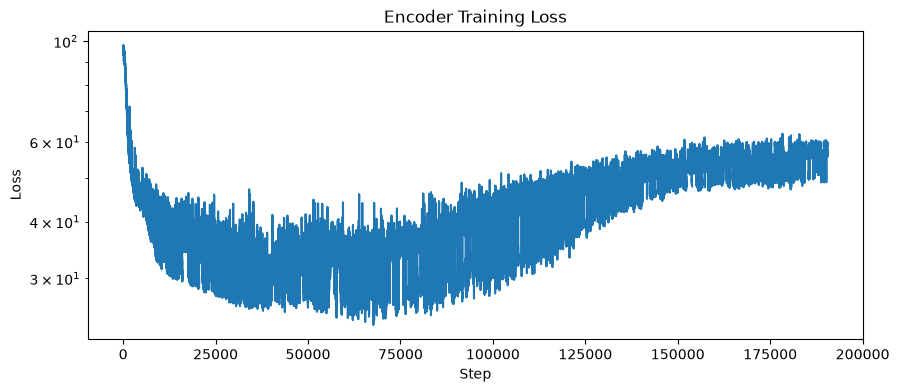

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(pt_results['loss_history'])
plt.yscale('log')
plt.title('Encoder Training Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

### Encoder Training Evals

In [ ]:
eval_config = {
    'num_genes': model_cfg.num_genes, 'embed_dim': model_cfg.embed_dim,
    'n_layer': model_cfg.n_layer, 'heads': model_cfg.heads, 'batch_size': encoder_cfg.batch_size, 'seed': SEED
}
model.eval()
eval_ctx = EvalContext(config=eval_config, data_root=data_cfg.data_root, checkpoint_root=data_cfg.data_root, ref_dir=data_cfg.ref_dir)
eval_ctx._biojepa = model
pt_eval_results = run_encoder_evals(eval_ctx)
eval_ctx._biojepa = None

save_report(pt_eval_results, data_cfg.eval_results_dir / 'encoder_eval_report.json')
pt_eval_results

In [14]:
del enc_train_loader, enc_val_loader, eval_ctx
gc.collect()
torch.cuda.empty_cache()
model.train()

BioJepa(
  (student): OptimizedModule(
    (_orig_mod): CellStateEncoder(
      (expr_scaler): Linear(in_features=1, out_features=1, bias=False)
      (fourier_input_scaler): Linear(in_features=1, out_features=1, bias=False)
      (fourier_projection): GaussianFourierProjection()
      (film_generator): Sequential(
        (0): Linear(in_features=256, out_features=256, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=256, out_features=512, bias=True)
      )
      (total_count_proj): Linear(in_features=1, out_features=256, bias=True)
      (blocks): ModuleList(
        (0-5): 6 x CellStateBlock(
          (ln_1): RMSNorm()
          (attn): BioLinearAttention(
            (q_proj): Linear(in_features=256, out_features=256, bias=True)
            (k_proj): Linear(in_features=256, out_features=256, bias=True)
            (v_proj): Linear(in_features=256, out_features=256, bias=True)
            (c_proj): Linear(in_features=256, out_features=256, bias=True)

## Stage 2: AC Training

In [15]:
train_loader = TrainingLoader(
    batch_size=ac_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'predictor_t', 
    device=device)
val_loader = TrainingLoader(
    batch_size=ac_cfg.batch_size, 
    split='val', data_dir=data_cfg.data_root / 'predictor_t', 
    device=device)

full_results = run_ac_training(model, train_loader, val_loader, seq_banks, target_bank, ac_cfg, device, data_cfg.checkpoint_dir, use_amp=USE_AMP, use_fused_optimizer=USE_FUSED)

found 1119 shards for split train
shard balancing (threshold=128, 20% of max=639):
  adamson: 22 -> 132 shards (x6)
  k562e_raw: 94 -> 188 shards (x2)
  k562gw: 639 shards
  norman: 35 -> 140 shards (x4)
  rep1e: 79 -> 158 shards (x2)
  sciplex: 250 shards
found 67 shards for split val
AC training: 3362117 samples, 52533 steps/epoch, 262665 total steps
Mask annealing: starts at step 157599 (0.766 -> 0.000)
Beta-NLL: target=0.95, anneal steps=105066
Step 0 | val loss: 126.6419
Step 0 | Loss: 111.76752 | LR: 1.60e-04 | Beta: 0.000
Step 1000 | Loss: 54.03770 | LR: 2.15e-04 | Beta: 0.009
Step 2000 | Loss: 45.01109 | LR: 3.76e-04 | Beta: 0.018
Step 3000 | Loss: 51.81059 | LR: 6.34e-04 | Beta: 0.027
Step 4000 | Loss: 48.22711 | LR: 9.74e-04 | Beta: 0.036
Step 5000 | val loss: 42.7327
Step 5000 | Loss: 42.32429 | LR: 1.38e-03 | Beta: 0.045
Step 6000 | Loss: 36.24680 | LR: 1.82e-03 | Beta: 0.054
Step 7000 | Loss: 38.44729 | LR: 2.28e-03 | Beta: 0.063
Step 8000 | Loss: 43.30946 | LR: 2.73e-03 |

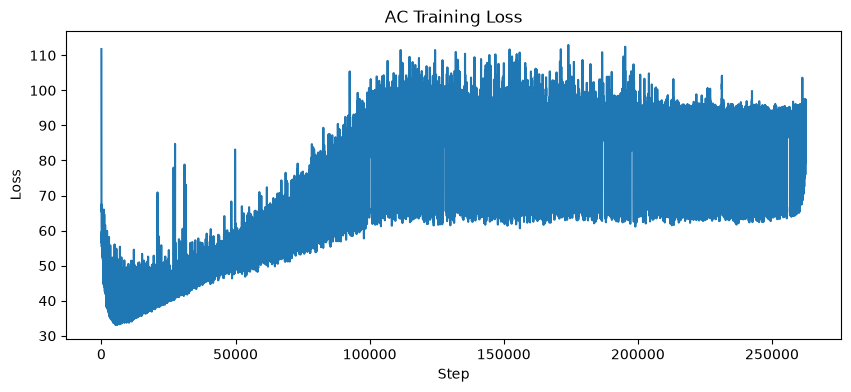

In [16]:
plt.figure(figsize=(10, 4))
plt.plot(full_results['loss_history'])
plt.title('AC Training Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

In [17]:
del train_loader, val_loader
gc.collect()
torch.cuda.empty_cache()

## Stage 3: Linear Decoder Training

In [18]:
decoder_train_loader = TrainingLoader(
    batch_size=decoder_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'predictor_t', 
    device=device)
decoder_val_loader = TrainingLoader(
    batch_size=decoder_cfg.batch_size,
    split='val', data_dir=data_cfg.data_root / 'predictor_t',
    device=device)

decoder, decoder_results = train_linear_decoder(model, decoder_train_loader, decoder_val_loader, seq_banks, target_bank, model_cfg, device, data_cfg.checkpoint_dir, decoder_cfg, use_amp=USE_AMP, use_fused_optimizer=USE_FUSED)

found 1119 shards for split train
shard balancing (threshold=128, 20% of max=639):
  adamson: 22 -> 132 shards (x6)
  k562e_raw: 94 -> 188 shards (x2)
  k562gw: 639 shards
  norman: 35 -> 140 shards (x4)
  rep1e: 79 -> 158 shards (x2)
  sciplex: 250 shards
found 67 shards for split val
Decoder training: 3857920 samples, 120560 steps/epoch, 602800 total steps


Autotune Choices Stats:
{"num_choices": 22, "num_triton_choices": 21, "best_kernel": "mm", "best_time": 0.19244800508022308, "best_triton_pos": 1, "best_triton_time": 0.32393598556518555, "best_triton_kernel": "triton_mm_4018", "best_triton_kernel_desc": "ACC_TYPE='tl.float32', ALLOW_TF32=False, BLOCK_K=32, BLOCK_M=128, BLOCK_N=128, EVEN_K=True, GROUP_M=8, USE_FAST_ACCUM=False, num_stages=3, num_warps=4"}
AUTOTUNE mm(320000x256, 256x704)
strides: [256, 1], [1, 256]
dtypes: torch.bfloat16, torch.bfloat16
  mm 0.1924 ms 100.0% 
  triton_mm_4018 0.3239 ms 59.4% ACC_TYPE='tl.float32', ALLOW_TF32=False, BLOCK_K=32, BLOCK_M=128, BLOCK_N=128, EVEN_K=True, GROUP_M=8, USE_FAST_ACCUM=False, num_stages=3, num_warps=4
  triton_mm_4019 0.3400 ms 56.6% ACC_TYPE='tl.float32', ALLOW_TF32=False, BLOCK_K=64, BLOCK_M=128, BLOCK_N=128, EVEN_K=True, GROUP_M=8, USE_FAST_ACCUM=False, num_stages=3, num_warps=4
  triton_mm_4022 0.3413 ms 56.4% ACC_TYPE='tl.float32', ALLOW_TF32=False, BLOCK_K=64, BLOCK_M=128, B

Decoder Step 0 | val loss: 1.5653
Decoder Step 0 | Loss: 2.01761
Decoder Step 1000 | Loss: 0.62704
Decoder Step 2000 | Loss: 0.32851
Decoder Step 3000 | Loss: 0.21928
Decoder Step 4000 | Loss: 0.18689
Decoder Step 5000 | val loss: 0.1836
Decoder Step 5000 | Loss: 0.16988
Decoder Step 6000 | Loss: 0.17594
Decoder Step 7000 | Loss: 0.19486
Decoder Step 8000 | Loss: 0.19947
Decoder Step 9000 | Loss: 0.16088
Decoder Step 10000 | val loss: 0.1739
Decoder Step 10000 | Loss: 0.15000
Decoder Step 11000 | Loss: 0.13951
Decoder Step 12000 | Loss: 0.42451
Decoder Step 13000 | Loss: 0.09803
Decoder Step 14000 | Loss: 0.15986
Decoder Step 15000 | val loss: 0.1742
Decoder Step 15000 | Loss: 0.16882
Decoder Step 16000 | Loss: 0.20443
Decoder Step 17000 | Loss: 0.16011
Decoder Step 18000 | Loss: 0.13785
Decoder Step 19000 | Loss: 0.16618
Decoder Step 20000 | val loss: 0.1732
Decoder Step 20000 | Loss: 0.17548
Decoder Step 21000 | Loss: 0.35534
Decoder Step 22000 | Loss: 0.12790
Decoder Step 23000 | Lo

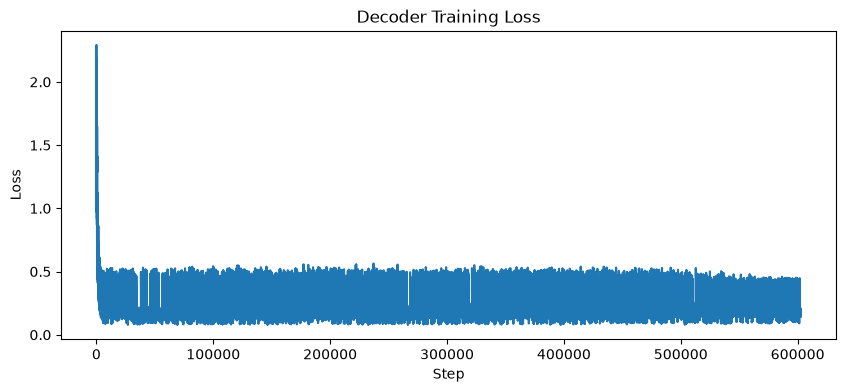

In [19]:
plt.figure(figsize=(10, 4))
plt.plot(decoder_results['loss_history'])
plt.title('Decoder Training Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

## AC Evals

In [ ]:
eval_config = {
    'num_genes': model_cfg.num_genes, 'embed_dim': model_cfg.embed_dim,
    'n_layer': model_cfg.n_layer, 'heads': model_cfg.heads, 'batch_size': ac_cfg.batch_size, 'seed': SEED
}
model.eval()
eval_ctx = EvalContext(config=eval_config, data_root=data_cfg.data_root, checkpoint_root=data_cfg.data_root, ref_dir=data_cfg.ref_dir)
eval_ctx._biojepa = model
eval_ctx._decoder = decoder
full_eval_results = run_ac_evals(eval_ctx)
eval_ctx._biojepa = None

save_report(full_eval_results, data_cfg.eval_results_dir / 'ac_eval_report.json')
full_eval_results

In [21]:
del decoder_train_loader, decoder_val_loader, eval_ctx
gc.collect()
torch.cuda.empty_cache()